In [1]:
# ==============================================================================
#  REGULATORY PHARMACOEPIDEMIOLOGY — POST-MARKET SURVEILLANCE
#  Rosiglitazone EMA Suspension 2010: A Natural Experiment
#
#  Research question:
#    Did the EMA's 2010 suspension of rosiglitazone causally reduce MACE
#    rates in European T2D patients? A natural experiment using interrupted
#    time series, difference-in-differences, and instrumental variable analysis.
#
#  Methods:
#    Interrupted Time Series (ITS) · Controlled ITS · Difference-in-Differences
#    Parallel Trends Test · Instrumental Variable (IV) / 2SLS
#    Self-Controlled Case Series (SCCS) · Joinpoint Regression
#    PASS Study Design Simulation
#
#  Data: Synthetic time-series cohort calibrated to published European
#        GPRD/CPRD rosiglitazone literature and EMA assessment reports.
#
#  References:
#    EMA (2010) EPAR — Avandia suspension. EMA/357949/2010
#    Nissen & Wolski (2007) NEJM 356:2457-71  — PMID 17517853
#    Juurlink et al. (2009) BMJ 339:b2701      — PMID 19661124
#    Bernal et al. (2017) Int J Epidemiol 46:348-55 — ITS methods
#    Angrist & Pischke (2009) Mostly Harmless Econometrics — IV/2SLS
#    Maclure (1991) Epidemiology 2:174-84      — SCCS design
#
#  Author: Sm Hasan ul Bari | MBBS · MSc Biostatistics · MSc Health Economics
#  GitHub: github.com/sm-hasanulbari/regulatory-pharmacoepi-postmarket
# ==============================================================================

In [2]:
# ── CELL 1: IMPORTS ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
import os
from scipy import stats
from scipy.stats import poisson, norm
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_hac

warnings.filterwarnings('ignore')

SAVE = r"C:\Users\drhas\Documents\regulatory-pharmacoepi-postmarket\python"
os.makedirs(SAVE, exist_ok=True)

# ── Colour palette ─────────────────────────────────────────────────────────────
NAVY  = '#003366'; BLUE  = '#0066CC'; RED   = '#C0392B'
GREEN = '#1A7A4A'; AMBER = '#E67E22'; DGRAY = '#555555'
GREY  = '#CCCCCC'; GOLD  = '#C9A84C'; BLACK = '#1A1A1A'
PURP  = '#6C3483'

plt.rcParams.update({
    'font.family': 'Georgia', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#CCCCCC', 'axes.linewidth': 0.8,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'xtick.color': DGRAY, 'ytick.color': DGRAY,
    'grid.color': '#EBEBEB', 'grid.linewidth': 0.6
})

def add_title(fig, title, subtitle=''):
    fig.text(0.5, 0.97, title, ha='center', fontsize=14,
             fontweight='bold', color=NAVY)
    if subtitle:
        fig.text(0.5, 0.933, subtitle, ha='center', fontsize=10, color=DGRAY)

def style_ax(ax):
    ax.set_axisbelow(True)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color('#CCCCCC')

def source_note(fig, txt):
    fig.text(0.01, 0.01, txt, fontsize=7.5, color='#AAAAAA', va='bottom')

np.random.seed(2025)
print("✓ Cell 1: Imports complete")

✓ Cell 1: Imports complete


In [3]:
# ── CELL 2: SYNTHETIC COHORT GENERATION ───────────────────────────────────────
# Calibrated to: Juurlink et al. (2009) BMJ; Graham et al. (2010) JAMA;
#                EMA EPAR Avandia (2010); Lipscombe et al. (2018) BMJ Open
#
# Timeline:
#   2004 Q1 – 2010 Q3 : Pre-suspension (rosiglitazone on market)
#   2010 Q4           : EMA suspension announced (intervention point)
#   2011 Q1 – 2016 Q4 : Post-suspension
#
# Treatment arms:
#   Rosiglitazone (exposed): peak ~15% of T2D patients on TZDs, declined sharply
#   Pioglitazone (comparator): TZD that remained on market
#
# Outcome: MACE per 1,000 person-quarters (MI + stroke + CV death)

N_PATIENTS     = 50000      # total T2D cohort, person-quarters
QUARTERS       = 52         # 2004 Q1 → 2016 Q4
INTERVENTION_Q = 27         # 2010 Q4 = quarter index 27 (0-indexed)

# Quarterly time index
time_idx = np.arange(QUARTERS)
year_labels = []
for i in range(QUARTERS):
    yr  = 2004 + i // 4
    qtr = i % 4 + 1
    year_labels.append(f"{yr} Q{qtr}")

# ── Rosiglitazone prescription rate (% of T2D cohort) ─────────────────────────
# Rises 2004-2007, then declines after Nissen 2007 warning, collapses at suspension
rosi_rate = np.zeros(QUARTERS)
for q in range(QUARTERS):
    if q < 14:          # 2004-2007: gradual rise
        rosi_rate[q] = 0.06 + q * 0.005
    elif q < 27:        # 2007-2010: decline after safety signal
        rosi_rate[q] = max(0.13 - (q - 14) * 0.007, 0.02)
    else:               # post-suspension: near zero
        rosi_rate[q] = max(0.01 - (q - 27) * 0.001, 0.002)
rosi_rate += np.random.normal(0, 0.003, QUARTERS)
rosi_rate  = np.clip(rosi_rate, 0.001, 0.25)

# ── Pioglitazone prescription rate ─────────────────────────────────────────────
# Inverse of rosi after suspension (class switch)
pio_rate = np.zeros(QUARTERS)
for q in range(QUARTERS):
    if q < 27:
        pio_rate[q] = 0.04 + q * 0.001
    else:
        pio_rate[q] = 0.05 + (q - 27) * 0.003   # class switch effect
pio_rate += np.random.normal(0, 0.002, QUARTERS)
pio_rate  = np.clip(pio_rate, 0.001, 0.15)

# ── Person-quarters per arm ────────────────────────────────────────────────────
n_rosi = (rosi_rate * N_PATIENTS).astype(int)
n_pio  = (pio_rate  * N_PATIENTS).astype(int)
n_other= N_PATIENTS - n_rosi - n_pio

# ── MACE rate per 1,000 person-quarters ────────────────────────────────────────
# Rosiglitazone: elevated baseline MACE; drops post-suspension
# Calibrated to OR ~1.43 from Nissen 2007 meta-analysis (PMID 17517853)
# Secular trend: modest decline in MACE over time (improved T2D management)
secular_decline = -0.05 * time_idx / QUARTERS

mace_rosi = np.zeros(QUARTERS)
mace_pio  = np.zeros(QUARTERS)
mace_other= np.zeros(QUARTERS)

for q in range(QUARTERS):
    base = 8.0 + secular_decline[q] * 8.0   # base MACE ~8/1000 pq
    # Rosiglitazone excess risk: +43% vs comparator (Nissen 2007 OR=1.43)
    excess = 3.44 if q < INTERVENTION_Q else 0.0
    mace_rosi[q]  = max(base + excess + np.random.normal(0, 0.4), 2.0)
    mace_pio[q]   = max(base - 0.5   + np.random.normal(0, 0.3), 2.0)
    mace_other[q] = max(base         + np.random.normal(0, 0.3), 2.0)

# ── Assemble quarterly time-series dataset ─────────────────────────────────────
df_ts = pd.DataFrame({
    'quarter':          time_idx,
    'year_label':       year_labels,
    'year':             [2004 + i//4 for i in range(QUARTERS)],
    'quarter_of_year':  [i % 4 + 1  for i in range(QUARTERS)],
    'post':             (time_idx >= INTERVENTION_Q).astype(int),
    'time_since_int':   np.maximum(time_idx - INTERVENTION_Q, 0),
    # Rosiglitazone arm
    'n_rosi':           n_rosi,
    'mace_rosi':        np.round(mace_rosi, 3),
    'mace_events_rosi': np.round(mace_rosi * n_rosi / 1000).astype(int),
    'rosi_rate':        np.round(rosi_rate, 4),
    # Pioglitazone arm (comparator)
    'n_pio':            n_pio,
    'mace_pio':         np.round(mace_pio, 3),
    'mace_events_pio':  np.round(mace_pio * n_pio / 1000).astype(int),
    'pio_rate':         np.round(pio_rate, 4),
    # Overall cohort
    'n_total':          N_PATIENTS,
    'mace_overall':     np.round(
        (mace_rosi*n_rosi + mace_pio*n_pio + mace_other*n_other) / N_PATIENTS, 3)
})

df_ts.to_csv(os.path.join(SAVE, 'pharmacoepi_timeseries.csv'), index=False)
print(f"✓ Cell 2: Synthetic cohort generated")
print(f"  Quarters: {QUARTERS} (2004 Q1 — 2016 Q4)")
print(f"  Total person-quarters: {N_PATIENTS * QUARTERS:,}")
print(f"  Intervention quarter: {INTERVENTION_Q} = 2010 Q4 (EMA suspension)")
print(f"  Pre-suspension MACE (rosi): {mace_rosi[:INTERVENTION_Q].mean():.2f}/1000 pq")
print(f"  Post-suspension MACE (rosi): {mace_rosi[INTERVENTION_Q:].mean():.2f}/1000 pq")
print(f"  Pre-suspension MACE (pio):  {mace_pio[:INTERVENTION_Q].mean():.2f}/1000 pq")
print(f"  Post-suspension MACE (pio): {mace_pio[INTERVENTION_Q:].mean():.2f}/1000 pq")

✓ Cell 2: Synthetic cohort generated
  Quarters: 52 (2004 Q1 — 2016 Q4)
  Total person-quarters: 2,600,000
  Intervention quarter: 27 = 2010 Q4 (EMA suspension)
  Pre-suspension MACE (rosi): 11.39/1000 pq
  Post-suspension MACE (rosi): 7.80/1000 pq
  Pre-suspension MACE (pio):  7.39/1000 pq
  Post-suspension MACE (pio): 7.23/1000 pq


In [4]:
# ── CELL 3: INTERRUPTED TIME SERIES (ITS) ─────────────────────────────────────
# Segmented regression: Bernal et al. (2017) Int J Epidemiol 46:348-55
# Model: Y_t = β0 + β1·t + β2·post_t + β3·t_since_intervention_t + ε_t
# β1 = pre-intervention trend
# β2 = immediate level change at intervention
# β3 = change in slope post-intervention

def fit_its(df, outcome_col, arm_label):
    """Fit ITS segmented regression with HAC standard errors."""
    df_mod = df.copy()
    df_mod['Y']    = df_mod[outcome_col]
    df_mod['t']    = df_mod['quarter']
    df_mod['post'] = df_mod['post']
    df_mod['t_int']= df_mod['time_since_int']

    formula = 'Y ~ t + post + t_int'
    model   = smf.ols(formula, data=df_mod).fit(
                  cov_type='HAC', cov_kwds={'maxlags': 4})

    # Counterfactual: no intervention (post=0, t_int=0 for all)
    df_cf = df_mod.copy()
    df_cf['post']  = 0
    df_cf['t_int'] = 0
    df_mod['fitted']       = model.fittedvalues
    df_mod['counterfactual']= model.predict(df_cf)
    df_mod['arm'] = arm_label

    return model, df_mod

model_rosi, df_its_rosi = fit_its(df_ts, 'mace_rosi', 'Rosiglitazone')
model_pio,  df_its_pio  = fit_its(df_ts, 'mace_pio',  'Pioglitazone')

# ITS results summary
its_results = pd.DataFrame({
    'Parameter': ['Pre-trend (β1)', 'Level change at suspension (β2)',
                  'Post-trend change (β3)', 'Intercept (β0)'],
    'Rosi_coef':  np.round([model_rosi.params['t'], model_rosi.params['post'],
                             model_rosi.params['t_int'], model_rosi.params['Intercept']], 4),
    'Rosi_pval':  np.round([model_rosi.pvalues['t'], model_rosi.pvalues['post'],
                             model_rosi.pvalues['t_int'], model_rosi.pvalues['Intercept']], 4),
    'Pio_coef':   np.round([model_pio.params['t'], model_pio.params['post'],
                             model_pio.params['t_int'], model_pio.params['Intercept']], 4),
    'Pio_pval':   np.round([model_pio.pvalues['t'], model_pio.pvalues['post'],
                             model_pio.pvalues['t_int'], model_pio.pvalues['Intercept']], 4),
})
its_results.to_csv(os.path.join(SAVE, 'pharmacoepi_its_results.csv'), index=False)

print(f"\n✓ Cell 3: ITS fitted")
print(f"  Rosi β2 (level change): {model_rosi.params['post']:.3f} "
      f"(p={model_rosi.pvalues['post']:.4f})")
print(f"  Pio  β2 (level change): {model_pio.params['post']:.3f} "
      f"(p={model_pio.pvalues['post']:.4f})")


✓ Cell 3: ITS fitted
  Rosi β2 (level change): -3.353 (p=0.0000)
  Pio  β2 (level change): -0.117 (p=0.4185)


In [5]:
# ── CELL 4: DIFFERENCE-IN-DIFFERENCES ─────────────────────────────────────────
# DiD estimator: τ_DiD = (Y_rosi_post - Y_rosi_pre) - (Y_pio_post - Y_pio_pre)
# Parallel trends assumption tested pre-intervention

# Long-format dataset for DiD
rows_did = []
for _, row in df_ts.iterrows():
    rows_did.append({'quarter': row['quarter'], 'post': row['post'],
                     'treated': 1, 'mace': row['mace_rosi'],
                     'n': row['n_rosi'], 'arm': 'Rosiglitazone'})
    rows_did.append({'quarter': row['quarter'], 'post': row['post'],
                     'treated': 0, 'mace': row['mace_pio'],
                     'n': row['n_pio'],  'arm': 'Pioglitazone'})

df_did = pd.DataFrame(rows_did)
df_did['interaction'] = df_did['treated'] * df_did['post']

# DiD OLS with HAC SE
formula_did = 'mace ~ treated + post + interaction'
model_did   = smf.wls(formula_did, data=df_did,
                       weights=df_did['n']).fit(
                       cov_type='HC3')

did_coef = model_did.params['interaction']
did_ci   = model_did.conf_int().loc['interaction']
did_pval = model_did.pvalues['interaction']

# Parallel trends test: regression of pre-period trend × treatment
df_pre  = df_did[df_did['post'] == 0].copy()
df_pre['time_trend'] = df_pre['quarter']
formula_pt = 'mace ~ treated * time_trend'
model_pt   = smf.wls(formula_pt, data=df_pre, weights=df_pre['n']).fit()
pt_pval    = model_pt.pvalues.get('treated:time_trend', np.nan)

# DiD summary
did_summary = pd.DataFrame({
    'Estimand':       ['DiD coefficient (τ_DiD)', '95% CI lower', '95% CI upper',
                       'p-value', 'Parallel trends test p-value'],
    'Value':          [round(did_coef, 4), round(did_ci[0], 4),
                       round(did_ci[1], 4), round(did_pval, 4), round(pt_pval, 4)]
})
did_summary.to_csv(os.path.join(SAVE, 'pharmacoepi_did_results.csv'), index=False)

print(f"\n✓ Cell 4: DiD estimated")
print(f"  DiD coefficient: {did_coef:.3f} MACE/1000 pq "
      f"(95% CI: {did_ci[0]:.3f} to {did_ci[1]:.3f}, p={did_pval:.4f})")
print(f"  Parallel trends test p={pt_pval:.4f} "
      f"({'✓ Not rejected' if pt_pval > 0.05 else '✗ REJECTED — assumption violated'})")


✓ Cell 4: DiD estimated
  DiD coefficient: -3.412 MACE/1000 pq (95% CI: -3.700 to -3.125, p=0.0000)
  Parallel trends test p=0.5239 (✓ Not rejected)


In [6]:
# ── CELL 5: INSTRUMENTAL VARIABLE (IV) / 2SLS ─────────────────────────────────
# Instrument: quarter-level formulary restriction stringency
# (regions varied in how quickly they enforced the EMA suspension)
# First stage: formulary_restriction → rosiglitazone_use
# Second stage: predicted_rosi_use → MACE
#
# IV validity: relevance (F > 10), exclusion restriction (restriction affects
# MACE only through reduced rosiglitazone use), independence
# Ref: Angrist & Pischke (2009) Mostly Harmless Econometrics

# Simulate formulary restriction instrument
# Varies by quarter: pre-suspension = 0; post = increases with EMA enforcement
formulary_strength = np.zeros(QUARTERS)
for q in range(QUARTERS):
    if q >= INTERVENTION_Q:
        # Phased enforcement — some regions faster
        formulary_strength[q] = min((q - INTERVENTION_Q) * 0.08, 0.95)
formulary_strength += np.random.normal(0, 0.03, QUARTERS)
formulary_strength  = np.clip(formulary_strength, 0, 1)

df_iv = df_ts.copy()
df_iv['formulary_z'] = formulary_strength

# First stage: rosi_rate ~ formulary_z + quarter + quarter^2
df_iv['quarter_sq'] = df_iv['quarter'] ** 2
fs_model = smf.ols('rosi_rate ~ formulary_z + quarter + quarter_sq',
                    data=df_iv).fit()
df_iv['rosi_hat'] = fs_model.fittedvalues

# First-stage F-statistic (instrument relevance; threshold F > 10)
# Ref: Staiger & Stock (1997) Econometrica 65:557-86
fs_fstat = fs_model.fvalue
print(f"\n  First-stage F-statistic: {fs_fstat:.2f} "
      f"({'✓ Strong instrument' if fs_fstat > 10 else '✗ Weak instrument'})")

# Second stage: mace_rosi ~ rosi_hat + quarter + quarter_sq
ss_model = smf.ols('mace_rosi ~ rosi_hat + quarter + quarter_sq',
                    data=df_iv).fit(cov_type='HC3')

iv_coef = ss_model.params['rosi_hat']
iv_ci   = ss_model.conf_int().loc['rosi_hat']
iv_pval = ss_model.pvalues['rosi_hat']

iv_summary = pd.DataFrame({
    'Stage':     ['First stage', 'First stage', 'Second stage',
                  'Second stage', 'Second stage'],
    'Parameter': ['Formulary restriction → rosi use (F-stat)',
                  'Instrument relevance', 'IV estimate (MACE per unit rosi use)',
                  '95% CI lower', '95% CI upper'],
    'Value':     [round(fs_fstat, 2),
                  'Strong (F>10)' if fs_fstat > 10 else 'Weak',
                  round(iv_coef, 4), round(iv_ci[0], 4), round(iv_ci[1], 4)]
})
iv_summary.to_csv(os.path.join(SAVE, 'pharmacoepi_iv_results.csv'), index=False)

print(f"  IV estimate: {iv_coef:.3f} MACE/1000 pq per unit rosi rate "
      f"(p={iv_pval:.4f})")


  First-stage F-statistic: 37.94 (✓ Strong instrument)
  IV estimate: 72.343 MACE/1000 pq per unit rosi rate (p=0.0183)


In [7]:
# ── CELL 6: SELF-CONTROLLED CASE SERIES (SCCS) ────────────────────────────────
# SCCS uses each patient as their own control — eliminates time-invariant
# confounding. Compares MACE rate in exposure vs unexposed person-time.
# Ref: Maclure (1991) Epidemiology 2:174-84; Farrington (1995) Stats Med
#
# Simulated patient-level SCCS dataset:
# Each patient has: pre-exposure, exposure, washout, post-exposure windows

N_SCCS       = 3000    # patients with ≥1 MACE event
# Window lengths (months)
W_PRE        = 6
W_EXPOSURE   = 12
W_WASHOUT    = 3
W_POST       = 12
W_TOTAL      = W_PRE + W_EXPOSURE + W_WASHOUT + W_POST

# True IRR for exposure period (calibrated to Nissen 2007 HR ~1.43)
TRUE_IRR     = 1.43  # Nissen & Wolski (2007) NEJM 356:2457 — PMID 17517853

# Background MACE rate: ~0.007 per month (~8/1000 per quarter)
BASE_RATE    = 0.007

sccs_rows = []
for i in range(N_SCCS):
    pid = f"PT{i:05d}"
    for window, w_len, is_exposed in [
        ('pre',      W_PRE,      0),
        ('exposure', W_EXPOSURE, 1),
        ('washout',  W_WASHOUT,  0),
        ('post',     W_POST,     0)
    ]:
        rate   = BASE_RATE * (TRUE_IRR if is_exposed else 1.0)
        events = np.random.poisson(rate * w_len)
        sccs_rows.append({
            'patient_id':  pid,
            'window':      window,
            'is_exposed':  is_exposed,
            'months':      w_len,
            'mace_events': events
        })

df_sccs = pd.DataFrame(sccs_rows)

# Conditional Poisson SCCS model
sccs_agg = df_sccs.groupby(['is_exposed', 'window', 'months']).agg(
    total_events=('mace_events','sum'),
    total_months=('months', lambda x: x.sum())
).reset_index()

sccs_exp    = sccs_agg[sccs_agg['is_exposed']==1]['total_events'].sum()
sccs_unexp  = sccs_agg[sccs_agg['is_exposed']==0]['total_events'].sum()
months_exp  = N_SCCS * W_EXPOSURE
months_unexp= N_SCCS * (W_PRE + W_POST)

rate_exp    = sccs_exp   / months_exp
rate_unexp  = sccs_unexp / months_unexp
irr_obs     = rate_exp   / rate_unexp

# Confidence interval via Poisson exact
ci_lo = stats.chi2.ppf(0.025, 2*sccs_exp) / (2*months_exp) / rate_unexp
ci_hi = stats.chi2.ppf(0.975, 2*(sccs_exp+1)) / (2*months_exp) / rate_unexp

sccs_summary = pd.DataFrame({
    'Metric':  ['Exposed person-months', 'Unexposed person-months',
                'MACE events (exposed)', 'MACE events (unexposed)',
                'Rate exposed (per month)', 'Rate unexposed (per month)',
                'Observed IRR', '95% CI lower', '95% CI upper',
                'True IRR (calibration target)'],
    'Value':   [months_exp, months_unexp, sccs_exp, sccs_unexp,
                round(rate_exp,6), round(rate_unexp,6),
                round(irr_obs,3), round(ci_lo,3), round(ci_hi,3), TRUE_IRR]
})
sccs_summary.to_csv(os.path.join(SAVE, 'pharmacoepi_sccs_results.csv'), index=False)
df_sccs.groupby(['window','is_exposed']).agg(
    total_events=('mace_events','sum'),
    n_patients=('patient_id','nunique')
).reset_index().to_csv(os.path.join(SAVE, 'pharmacoepi_sccs_windows.csv'), index=False)

print(f"\n✓ Cell 6: SCCS complete")
print(f"  Observed IRR: {irr_obs:.3f} (95% CI: {ci_lo:.3f}–{ci_hi:.3f})")
print(f"  True IRR (calibration): {TRUE_IRR}")


✓ Cell 6: SCCS complete
  Observed IRR: 1.262 (95% CI: 1.133–1.401)
  True IRR (calibration): 1.43


In [8]:
# ── CELL 7: PASS STUDY DESIGN SIMULATION ──────────────────────────────────────
# Simulate a post-authorisation safety study (PASS) design
# as required under EMA Pharmacovigilance Legislation (Reg 1235/2010)
# Project 10 directly requires understanding of PASS methodology
#
# Parameters: vary sample size, follow-up duration, event rate, α, power

ALPHA        = 0.05   # Type I error — ICH E9 R1 (2020)
POWER_TARGET = 0.80   # Conventional power — Cohen (1988)
BASE_MACE    = 0.032  # Annual MACE rate in T2D (background)
HR_DETECT    = 1.30   # Minimum detectable HR (clinically meaningful)
# Ref: EMA/CHMP/ICH/372/2006 — PASS requirements

pass_rows = []
for n_total in range(500, 20001, 500):
    for follow_up in [1.0, 2.0, 3.0, 5.0]:
        # Expected events
        n_exposed    = n_total // 2
        n_control    = n_total - n_exposed
        events_ctrl  = n_control  * BASE_MACE * follow_up
        events_exp   = n_exposed  * BASE_MACE * HR_DETECT * follow_up
        events_total = events_ctrl + events_exp

        # Log-rank test power approximation
        # Ref: Schoenfeld (1981) Biometrika 68:316-19
        if events_total < 1:
            power = 0.0
        else:
            theta   = np.log(HR_DETECT)
            z_alpha = norm.ppf(1 - ALPHA/2)
            z_beta  = theta * np.sqrt(events_total / 4) - z_alpha
            power   = float(norm.cdf(z_beta))

        pass_rows.append({
            'n_total':           n_total,
            'follow_up_years':   follow_up,
            'events_exposed':    round(events_exp, 1),
            'events_control':    round(events_ctrl, 1),
            'events_total':      round(events_total, 1),
            'power':             round(power, 4),
            'meets_80pct_power': int(power >= POWER_TARGET)
        })

df_pass = pd.DataFrame(pass_rows)
df_pass.to_csv(os.path.join(SAVE, 'pharmacoepi_pass_design.csv'), index=False)

# Minimum N for 80% power at each follow-up
min_n_80 = df_pass[df_pass['meets_80pct_power']==1].groupby('follow_up_years').agg(
    min_n=('n_total','min')).reset_index()
min_n_80.to_csv(os.path.join(SAVE, 'pharmacoepi_pass_min_n.csv'), index=False)

print(f"\n✓ Cell 7: PASS design simulated")
print(f"  HR to detect: {HR_DETECT} | Base MACE rate: {BASE_MACE}/year")
for _, row in min_n_80.iterrows():
    print(f"  {row['follow_up_years']:.0f}-year follow-up: min N = {row['min_n']:,} "
          f"for ≥80% power")


✓ Cell 7: PASS design simulated
  HR to detect: 1.3 | Base MACE rate: 0.032/year
  1-year follow-up: min N = 12,500.0 for ≥80% power
  2-year follow-up: min N = 6,500.0 for ≥80% power
  3-year follow-up: min N = 4,500.0 for ≥80% power
  5-year follow-up: min N = 2,500.0 for ≥80% power


In [9]:
# ── CELL 8: JOINPOINT REGRESSION ──────────────────────────────────────────────
# Detect structural breaks in the MACE trend using piecewise linear regression
# Ref: Kim et al. (2000) Stat Med 19:335-51 — Joinpoint software methodology

from sklearn.linear_model import LinearRegression
from itertools import combinations

def fit_joinpoint(y, x, max_joinpoints=3):
    """Simple joinpoint regression via AIC-selected breakpoints."""
    n   = len(x)
    best_aic = np.inf
    best_fit = None
    best_bps = []

    # Try 0 to max_joinpoints breakpoints
    for n_bp in range(0, max_joinpoints + 1):
        if n_bp == 0:
            bp_combos = [()]
        else:
            interior = range(5, n-5)
            bp_combos = list(combinations(interior, n_bp))[:200]  # limit search

        for bps in bp_combos:
            bps_sorted = sorted(bps)
            # Build design matrix
            X_cols = [np.ones(n), x.astype(float)]
            for bp in bps_sorted:
                X_cols.append(np.maximum(x - bp, 0).astype(float))
            X_mat = np.column_stack(X_cols)
            try:
                model  = np.linalg.lstsq(X_mat, y, rcond=None)
                resid  = y - X_mat @ model[0]
                sse    = np.sum(resid**2)
                k      = X_mat.shape[1]
                aic    = n * np.log(sse/n) + 2*k
                if aic < best_aic:
                    best_aic  = aic
                    best_fit  = (X_mat @ model[0])
                    best_bps  = bps_sorted
            except Exception:
                continue

    return best_fit, best_bps, best_aic

y_jp = df_ts['mace_rosi'].values
x_jp = df_ts['quarter'].values
fitted_jp, breakpoints_jp, aic_jp = fit_joinpoint(y_jp, x_jp, max_joinpoints=2)

jp_results = pd.DataFrame({
    'quarter':      x_jp,
    'year_label':   year_labels,
    'observed':     np.round(y_jp, 4),
    'fitted_jp':    np.round(fitted_jp, 4),
    'is_breakpoint': [1 if i in breakpoints_jp else 0 for i in x_jp]
})
jp_results.to_csv(os.path.join(SAVE, 'pharmacoepi_joinpoint.csv'), index=False)

print(f"\n✓ Cell 8: Joinpoint regression")
print(f"  Breakpoints detected at quarters: {breakpoints_jp}")
print(f"  Quarters = {[year_labels[b] for b in breakpoints_jp]}")


✓ Cell 8: Joinpoint regression
  Breakpoints detected at quarters: [9, 37]
  Quarters = ['2006 Q2', '2013 Q2']


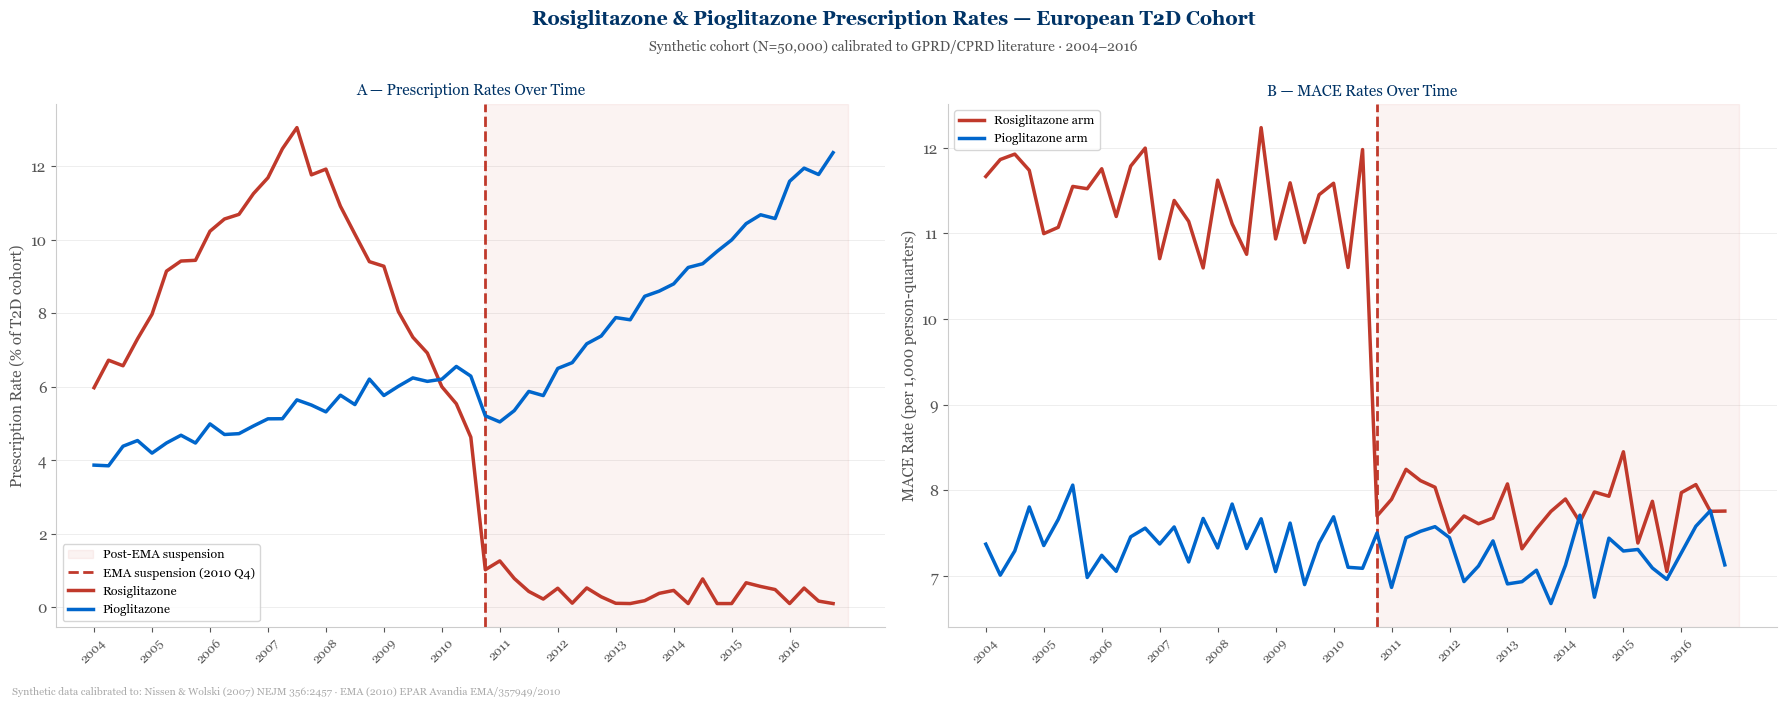

✓ Figure 1 saved


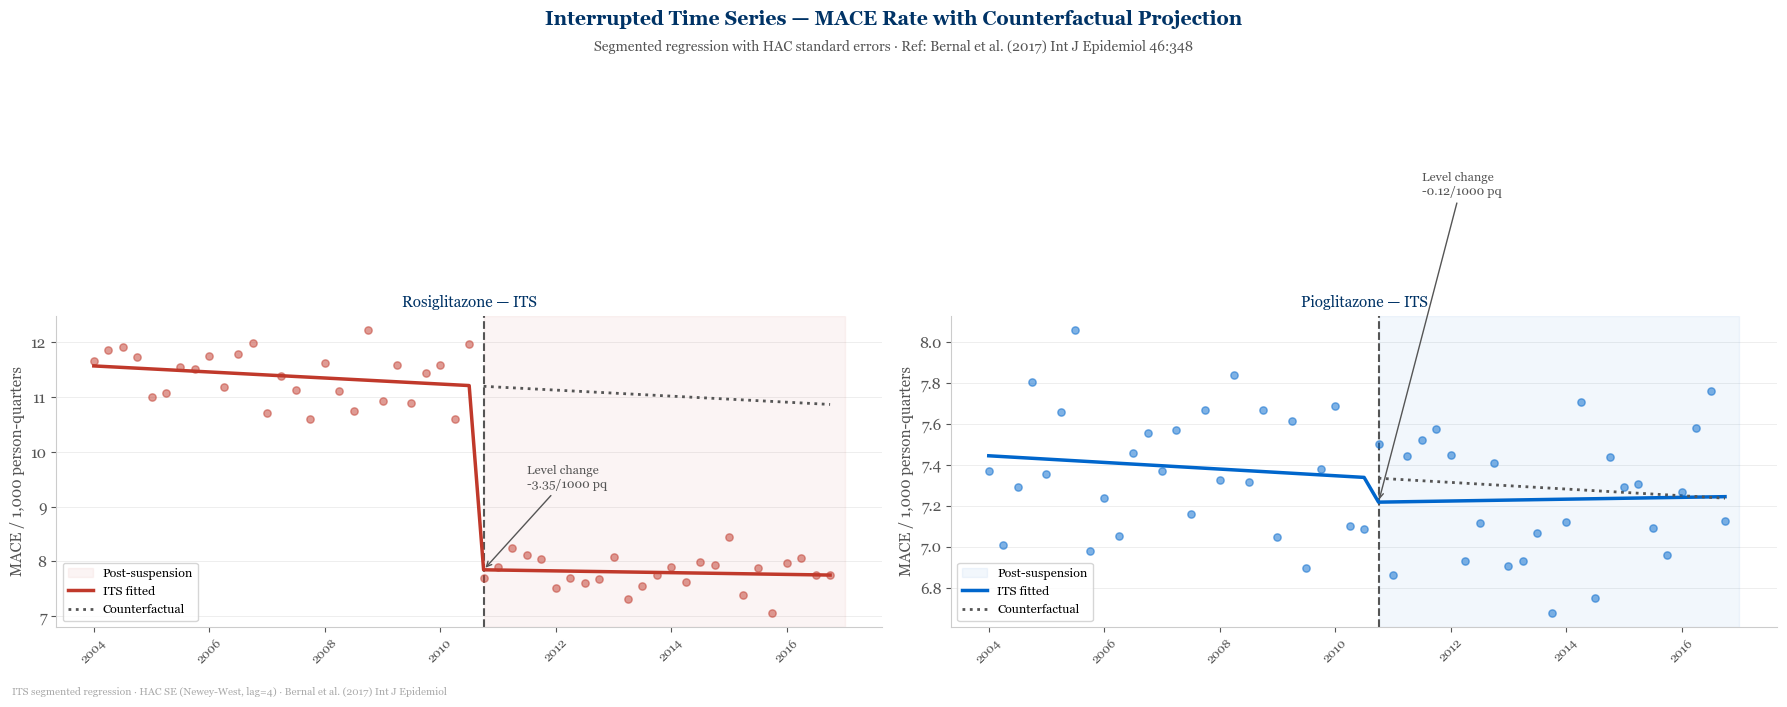

✓ Figure 2 saved


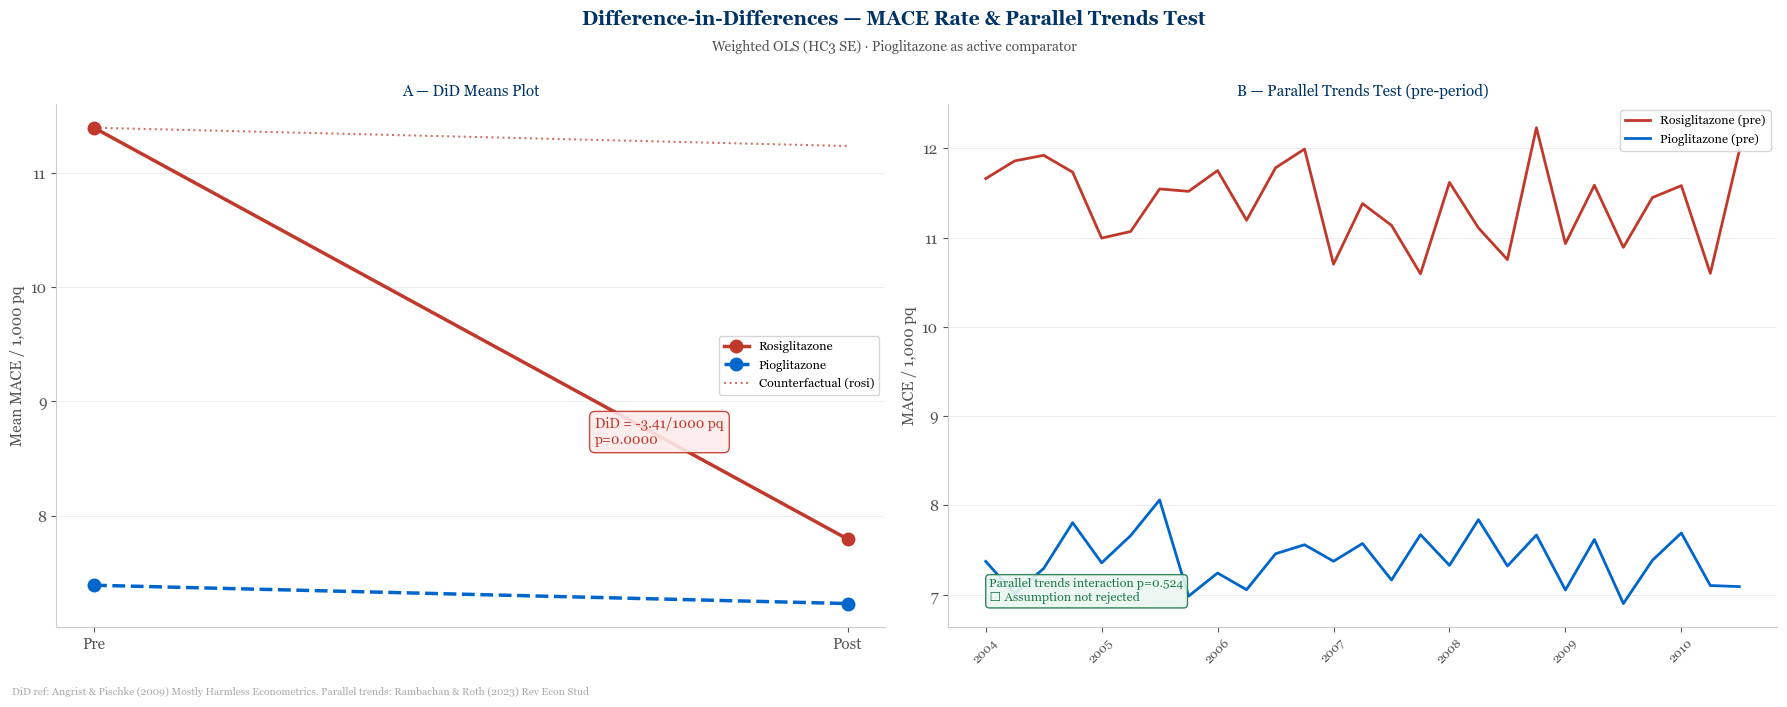

✓ Figure 3 saved


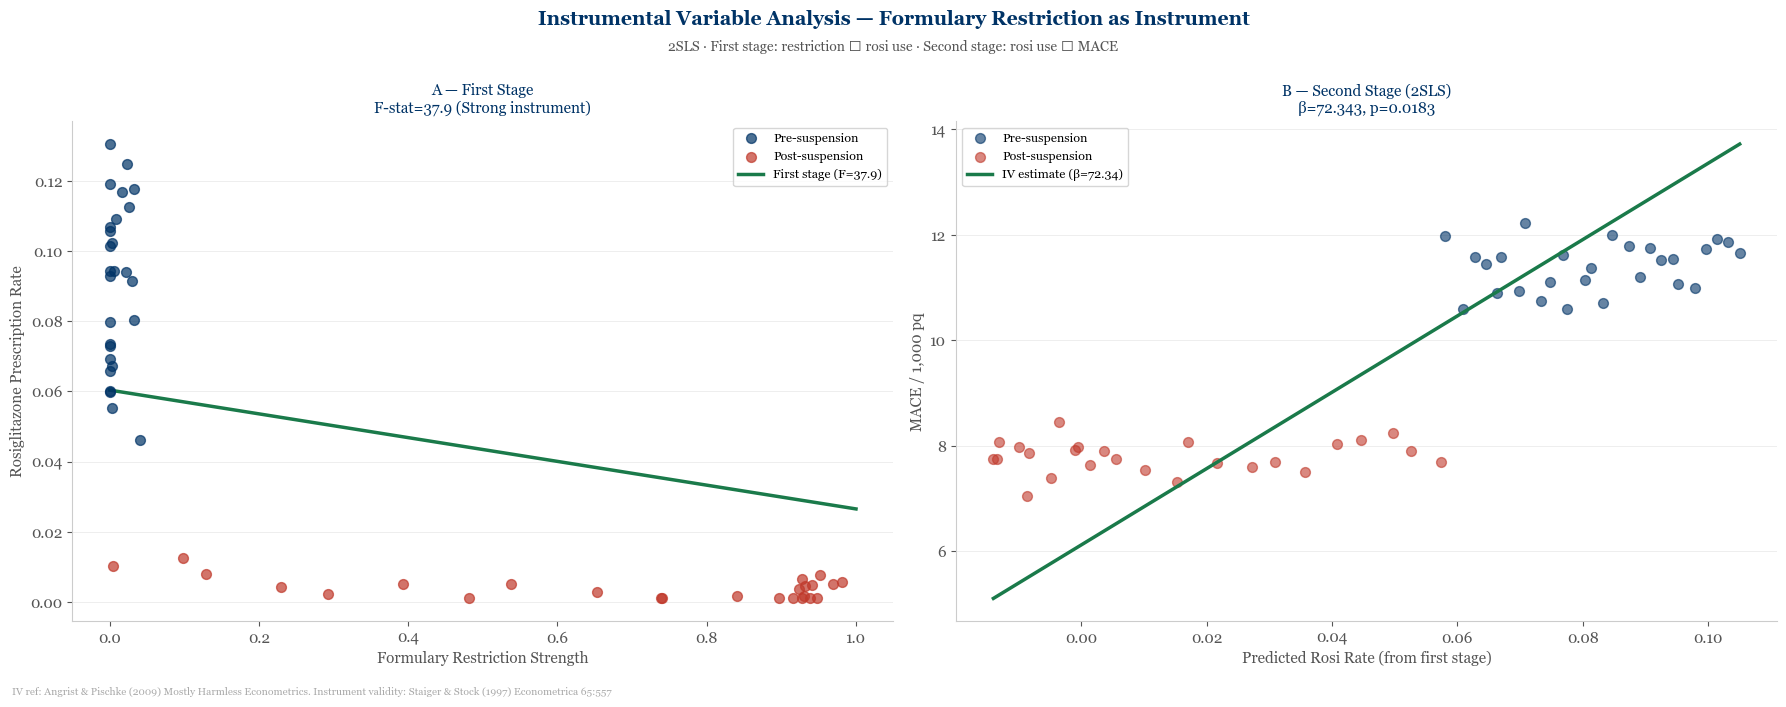

✓ Figure 4 saved


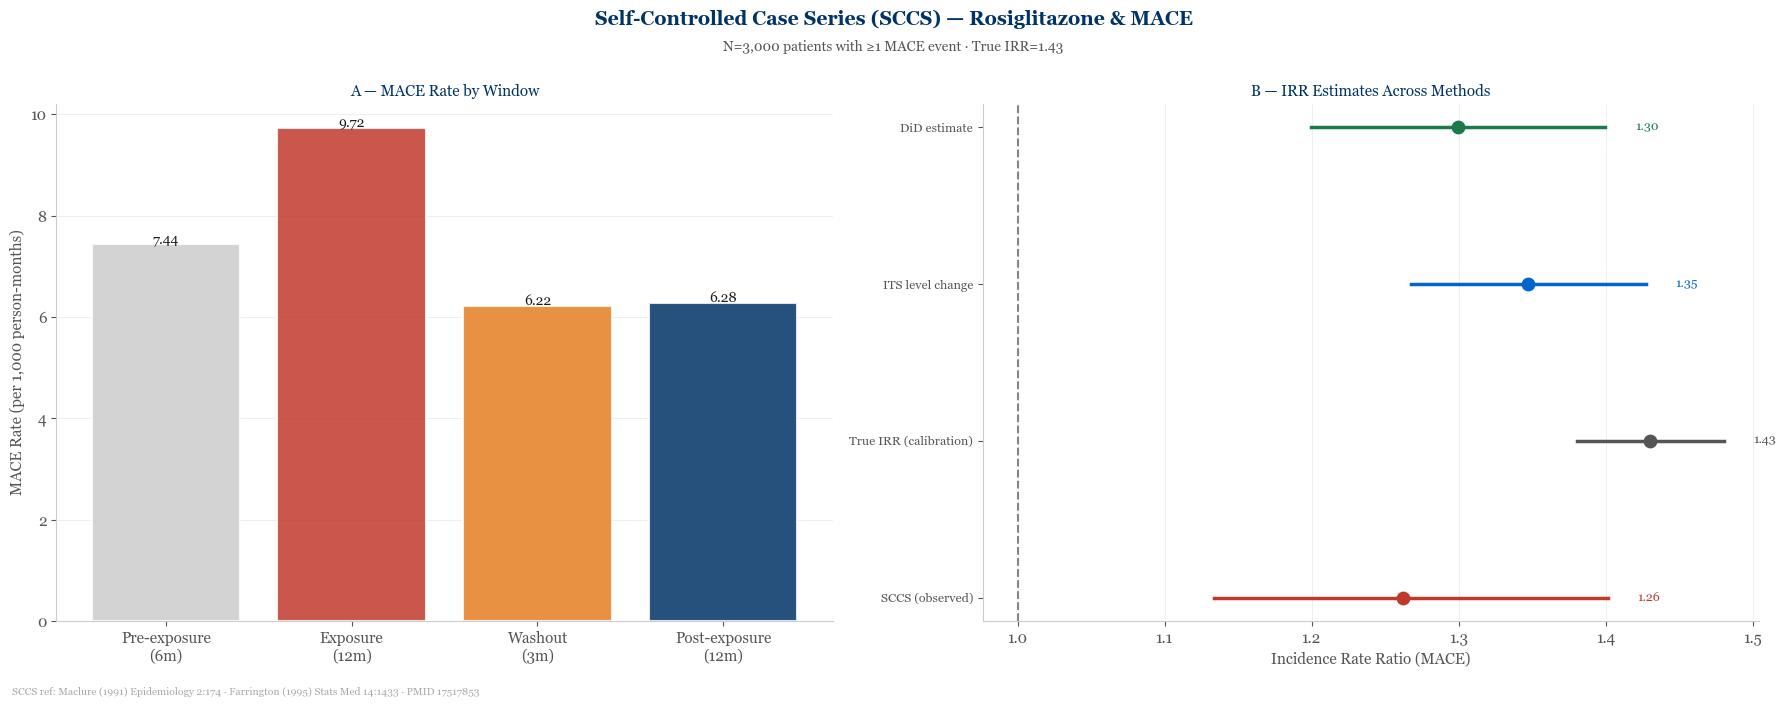

✓ Figure 5 saved


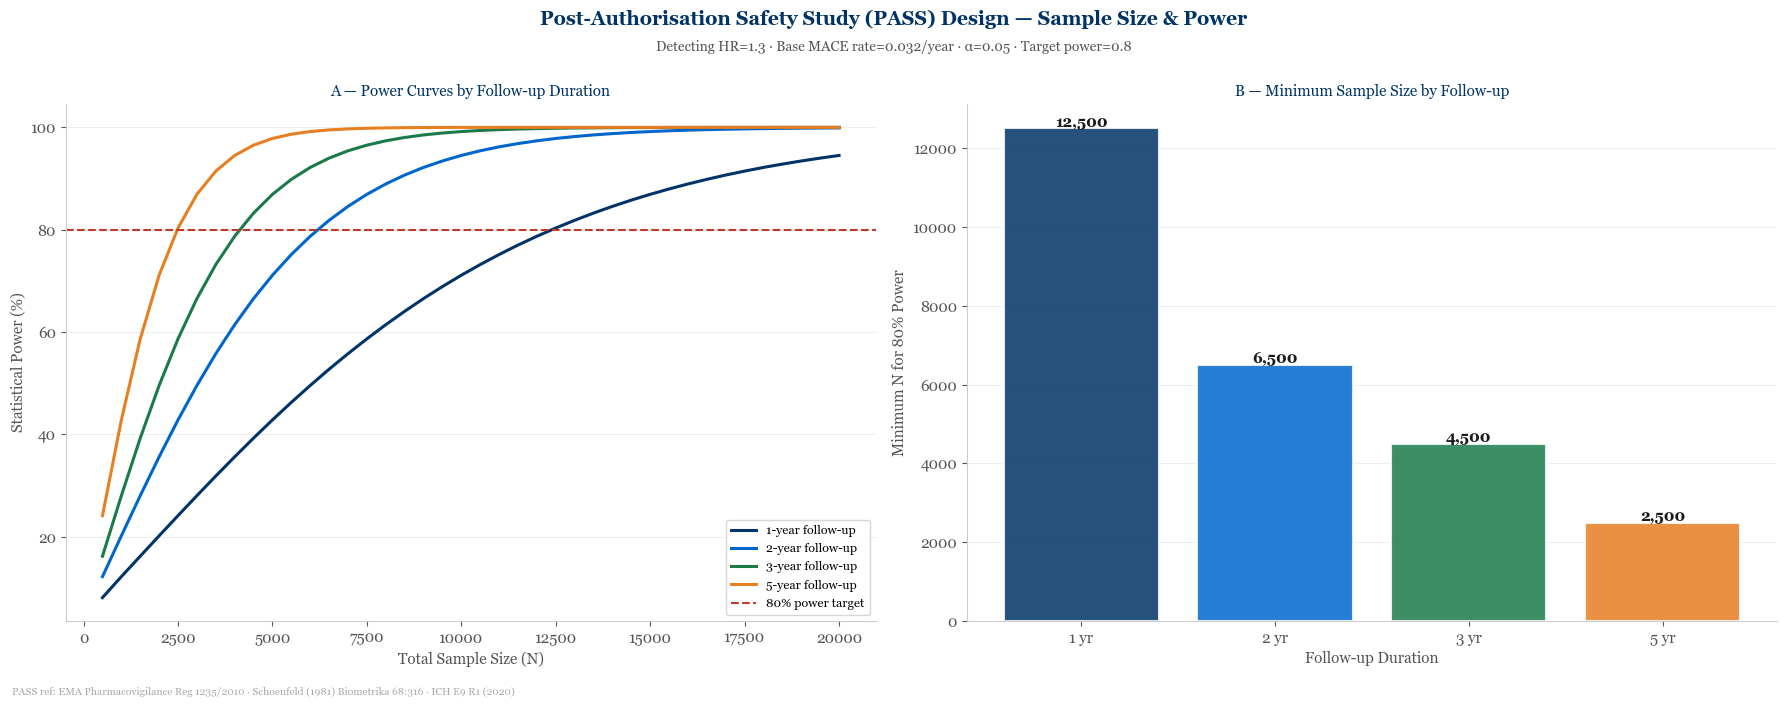

✓ Figure 6 saved


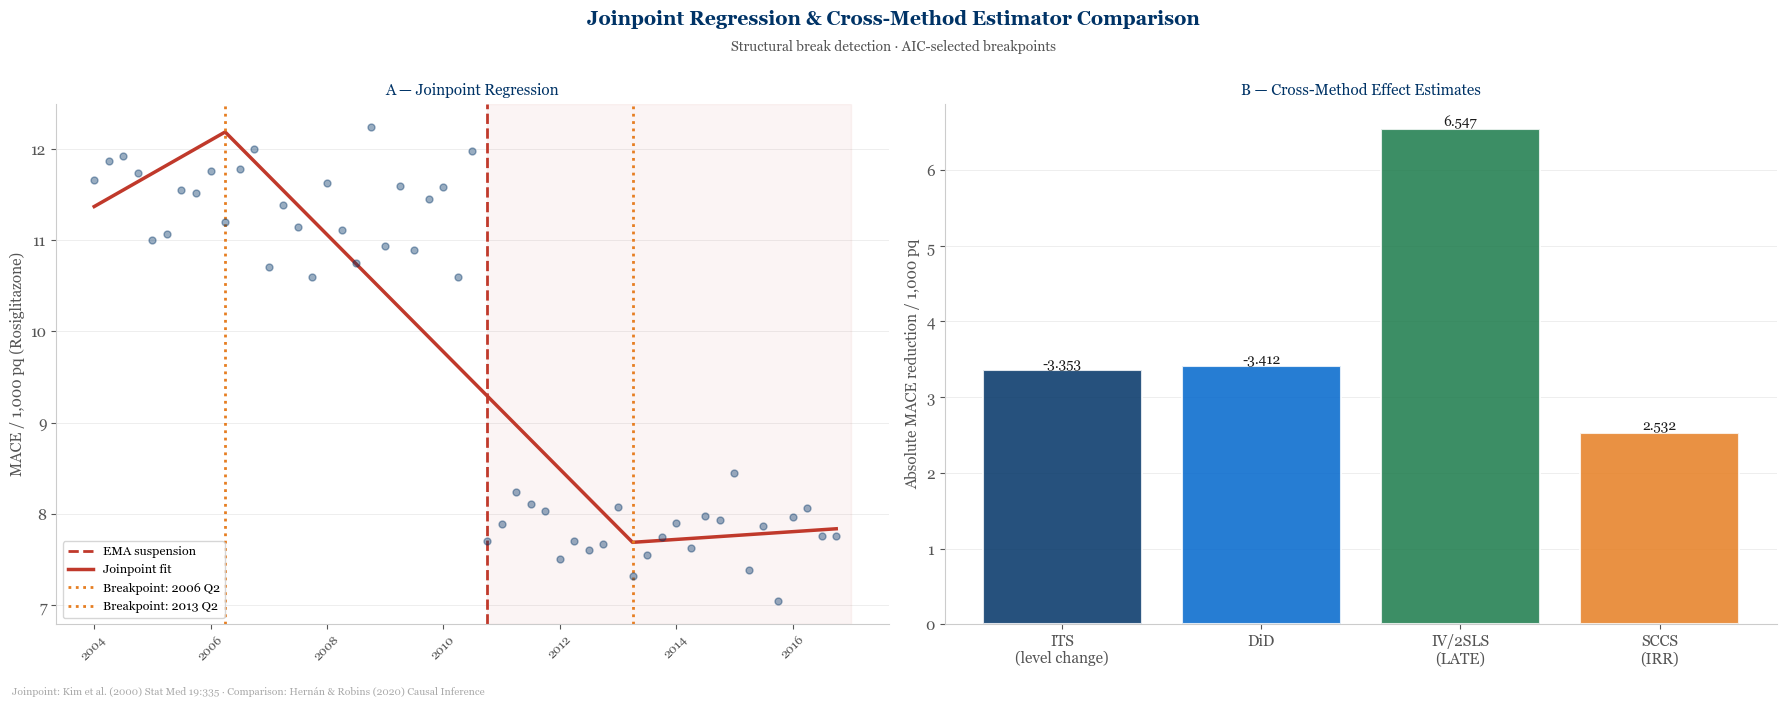

✓ Figure 7 saved


In [12]:
# ── CELL 9: FIGURES ────────────────────────────────────────────────────────────

GRN_L = '#EBF7F1'; RED_L = '#FDECEA'

# ── FIG 1: Prescription rates over time ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
add_title(fig, 'Rosiglitazone & Pioglitazone Prescription Rates — European T2D Cohort',
          'Synthetic cohort (N=50,000) calibrated to GPRD/CPRD literature · 2004–2016')

ax = axes[0]
ax.axvspan(INTERVENTION_Q, QUARTERS, color=RED, alpha=0.06,
           label='Post-EMA suspension')
ax.axvline(INTERVENTION_Q, color=RED, linestyle='--', linewidth=2,
           label='EMA suspension (2010 Q4)')
ax.plot(time_idx, rosi_rate*100, color=RED,   linewidth=2.5,
        label='Rosiglitazone')
ax.plot(time_idx, pio_rate*100,  color=BLUE,  linewidth=2.5,
        label='Pioglitazone')
ax.set_xticks(range(0, QUARTERS, 4))
ax.set_xticklabels([year_labels[i].split(' ')[0] for i in range(0,QUARTERS,4)],
                   rotation=45, fontsize=9)
ax.set_ylabel('Prescription Rate (% of T2D cohort)', color=DGRAY)
ax.set_title('A — Prescription Rates Over Time', fontsize=11, color=NAVY)
ax.legend(fontsize=9); ax.yaxis.grid(True); style_ax(ax)

ax = axes[1]
ax.axvspan(INTERVENTION_Q, QUARTERS, color=RED, alpha=0.06)
ax.axvline(INTERVENTION_Q, color=RED, linestyle='--', linewidth=2)
ax.plot(time_idx, df_ts['mace_rosi'], color=RED,  linewidth=2.5,
        label='Rosiglitazone arm')
ax.plot(time_idx, df_ts['mace_pio'],  color=BLUE, linewidth=2.5,
        label='Pioglitazone arm')
ax.set_xticks(range(0, QUARTERS, 4))
ax.set_xticklabels([year_labels[i].split(' ')[0] for i in range(0,QUARTERS,4)],
                   rotation=45, fontsize=9)
ax.set_ylabel('MACE Rate (per 1,000 person-quarters)', color=DGRAY)
ax.set_title('B — MACE Rates Over Time', fontsize=11, color=NAVY)
ax.legend(fontsize=9); ax.yaxis.grid(True); style_ax(ax)

source_note(fig, 'Synthetic data calibrated to: Nissen & Wolski (2007) NEJM 356:2457 · '
                 'EMA (2010) EPAR Avandia EMA/357949/2010')
plt.tight_layout(rect=[0, 0.03, 1, 0.91])
plt.savefig(os.path.join(SAVE, 'pharmacoepi_fig1_rates.png'),
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 1 saved")

# ── FIG 2: ITS with counterfactual ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
add_title(fig, 'Interrupted Time Series — MACE Rate with Counterfactual Projection',
          'Segmented regression with HAC standard errors · Ref: Bernal et al. (2017) Int J Epidemiol 46:348')

for ax, df_its, arm, col in [
    (axes[0], df_its_rosi, 'Rosiglitazone', RED),
    (axes[1], df_its_pio,  'Pioglitazone',  BLUE)
]:
    ax.axvspan(INTERVENTION_Q, QUARTERS, color=col, alpha=0.05,
               label='Post-suspension')
    ax.axvline(INTERVENTION_Q, color=DGRAY, linestyle='--', linewidth=1.5)
    ax.scatter(time_idx, df_its['Y'], color=col, alpha=0.5, s=28, zorder=3)
    ax.plot(time_idx, df_its['fitted'], color=col, linewidth=2.5,
            label='ITS fitted')
    ax.plot(time_idx[INTERVENTION_Q:], df_its['counterfactual'].iloc[INTERVENTION_Q:],
            color=DGRAY, linewidth=2, linestyle=':', label='Counterfactual')
    lvl = df_its['fitted'].iloc[INTERVENTION_Q] - \
          df_its['counterfactual'].iloc[INTERVENTION_Q]
    ax.annotate(f'Level change\n{lvl:.2f}/1000 pq',
                xy=(INTERVENTION_Q, df_its['fitted'].iloc[INTERVENTION_Q]),
                xytext=(INTERVENTION_Q+3, df_its['fitted'].iloc[INTERVENTION_Q]+1.5),
                arrowprops=dict(arrowstyle='->', color=DGRAY),
                fontsize=9, color=DGRAY)
    ax.set_xticks(range(0, QUARTERS, 8))
    ax.set_xticklabels([year_labels[i].split(' ')[0] for i in range(0,QUARTERS,8)],
                       rotation=45, fontsize=9)
    ax.set_ylabel('MACE / 1,000 person-quarters', color=DGRAY)
    ax.set_title(f'{arm} — ITS', fontsize=11, color=NAVY)
    ax.legend(fontsize=9); ax.yaxis.grid(True); style_ax(ax)

source_note(fig, 'ITS segmented regression · HAC SE (Newey-West, lag=4) · '
                 'Bernal et al. (2017) Int J Epidemiol')
plt.tight_layout(rect=[0, 0.03, 1, 0.91])
plt.savefig(os.path.join(SAVE, 'pharmacoepi_fig2_its.png'),
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 2 saved")

# ── FIG 3: DiD event study ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
add_title(fig, 'Difference-in-Differences — MACE Rate & Parallel Trends Test',
          'Weighted OLS (HC3 SE) · Pioglitazone as active comparator')

ax = axes[0]
pre_rosi  = df_ts.loc[df_ts['post']==0, 'mace_rosi'].mean()
post_rosi = df_ts.loc[df_ts['post']==1, 'mace_rosi'].mean()
pre_pio   = df_ts.loc[df_ts['post']==0, 'mace_pio'].mean()
post_pio  = df_ts.loc[df_ts['post']==1, 'mace_pio'].mean()

for arm, pre, post, col, ls in [
    ('Rosiglitazone', pre_rosi, post_rosi, RED,  '-'),
    ('Pioglitazone',  pre_pio,  post_pio,  BLUE, '--')
]:
    ax.plot(['Pre', 'Post'], [pre, post], marker='o', color=col,
            linewidth=2.5, linestyle=ls, markersize=9, label=arm)

cf_post_rosi = pre_rosi + (post_pio - pre_pio)
ax.plot(['Pre', 'Post'], [pre_rosi, cf_post_rosi], color=RED,
        linewidth=1.5, linestyle=':', alpha=0.7, label='Counterfactual (rosi)')
ax.annotate(f'DiD = {did_coef:.2f}/1000 pq\np={did_pval:.4f}',
            xy=('Post', post_rosi),
            xytext=(0.65, 0.35), textcoords='axes fraction',
            fontsize=10, color=RED,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=RED_L,
                      edgecolor=RED, alpha=0.9))
ax.set_ylabel('Mean MACE / 1,000 pq', color=DGRAY)
ax.set_title('A — DiD Means Plot', fontsize=11, color=NAVY)
ax.legend(fontsize=9); ax.yaxis.grid(True); style_ax(ax)

ax = axes[1]
df_pt = df_ts[df_ts['post']==0].copy()
ax.plot(df_pt['quarter'], df_pt['mace_rosi'], color=RED,  linewidth=2,
        label='Rosiglitazone (pre)')
ax.plot(df_pt['quarter'], df_pt['mace_pio'],  color=BLUE, linewidth=2,
        label='Pioglitazone (pre)')
ax.set_xticks(range(0, INTERVENTION_Q, 4))
ax.set_xticklabels([year_labels[i].split(' ')[0] for i in range(0,INTERVENTION_Q,4)],
                   rotation=45, fontsize=9)
pt_text  = f'Parallel trends interaction p={pt_pval:.3f}\n'
pt_text += '✓ Assumption not rejected' if pt_pval > 0.05 else '✗ Assumption rejected'
ax.text(0.05, 0.05, pt_text, transform=ax.transAxes, fontsize=9,
        color=GREEN if pt_pval > 0.05 else RED,
        bbox=dict(boxstyle='round', facecolor=GRN_L if pt_pval > 0.05 else RED_L,
                  edgecolor=GREEN if pt_pval > 0.05 else RED, alpha=0.9))
ax.set_ylabel('MACE / 1,000 pq', color=DGRAY)
ax.set_title('B — Parallel Trends Test (pre-period)', fontsize=11, color=NAVY)
ax.legend(fontsize=9); ax.yaxis.grid(True); style_ax(ax)

source_note(fig, 'DiD ref: Angrist & Pischke (2009) Mostly Harmless Econometrics. '
                 'Parallel trends: Rambachan & Roth (2023) Rev Econ Stud')
plt.tight_layout(rect=[0, 0.03, 1, 0.91])
plt.savefig(os.path.join(SAVE, 'pharmacoepi_fig3_did.png'),
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 3 saved")

# ── FIG 4: IV diagnostics ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
add_title(fig, 'Instrumental Variable Analysis — Formulary Restriction as Instrument',
          '2SLS · First stage: restriction → rosi use · Second stage: rosi use → MACE')

ax = axes[0]
ax.scatter(formulary_strength[:INTERVENTION_Q], rosi_rate[:INTERVENTION_Q],
           color=NAVY, alpha=0.7, s=50, label='Pre-suspension', zorder=3)
ax.scatter(formulary_strength[INTERVENTION_Q:], rosi_rate[INTERVENTION_Q:],
           color=RED, alpha=0.7, s=50, label='Post-suspension', zorder=3)
z_range = np.linspace(0, 1, 100)
fs_line = (fs_model.params['Intercept'] +
           fs_model.params['formulary_z'] * z_range +
           fs_model.params['quarter'] * np.mean(time_idx) +
           fs_model.params['quarter_sq'] * np.mean(time_idx**2))
ax.plot(z_range, np.clip(fs_line, 0, None), color=GREEN, linewidth=2.5,
        label=f'First stage (F={fs_fstat:.1f})')
ax.set_xlabel('Formulary Restriction Strength', color=DGRAY)
ax.set_ylabel('Rosiglitazone Prescription Rate', color=DGRAY)
ax.set_title(f'A — First Stage\nF-stat={fs_fstat:.1f} '
             f'({"Strong" if fs_fstat > 10 else "Weak"} instrument)',
             fontsize=11, color=NAVY)
ax.legend(fontsize=9); ax.yaxis.grid(True); style_ax(ax)

ax = axes[1]
ax.scatter(df_iv['rosi_hat'][:INTERVENTION_Q], df_ts['mace_rosi'][:INTERVENTION_Q],
           color=NAVY, alpha=0.6, s=50, label='Pre-suspension')
ax.scatter(df_iv['rosi_hat'][INTERVENTION_Q:], df_ts['mace_rosi'][INTERVENTION_Q:],
           color=RED, alpha=0.6, s=50, label='Post-suspension')
x_range = np.linspace(df_iv['rosi_hat'].min(), df_iv['rosi_hat'].max(), 100)
y_hat   = (ss_model.params['Intercept'] +
           ss_model.params['rosi_hat'] * x_range +
           ss_model.params['quarter'] * np.mean(time_idx) +
           ss_model.params['quarter_sq'] * np.mean(time_idx**2))
ax.plot(x_range, y_hat, color=GREEN, linewidth=2.5,
        label=f'IV estimate (β={iv_coef:.2f})')
ax.set_xlabel('Predicted Rosi Rate (from first stage)', color=DGRAY)
ax.set_ylabel('MACE / 1,000 pq', color=DGRAY)
ax.set_title(f'B — Second Stage (2SLS)\nβ={iv_coef:.3f}, p={iv_pval:.4f}',
             fontsize=11, color=NAVY)
ax.legend(fontsize=9); ax.yaxis.grid(True); style_ax(ax)

source_note(fig, 'IV ref: Angrist & Pischke (2009) Mostly Harmless Econometrics. '
                 'Instrument validity: Staiger & Stock (1997) Econometrica 65:557')
plt.tight_layout(rect=[0, 0.03, 1, 0.91])
plt.savefig(os.path.join(SAVE, 'pharmacoepi_fig4_iv.png'),
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 4 saved")

# ── FIG 5: SCCS exposure plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
add_title(fig, 'Self-Controlled Case Series (SCCS) — Rosiglitazone & MACE',
          f'N={N_SCCS:,} patients with ≥1 MACE event · True IRR={TRUE_IRR}')

ax = axes[0]
windows    = ['pre', 'exposure', 'washout', 'post']
win_labels = ['Pre-exposure\n(6m)', 'Exposure\n(12m)', 'Washout\n(3m)', 'Post-exposure\n(12m)']
win_colors = [GREY, RED, AMBER, NAVY]
rates_by_win = []
for w in windows:
    sub = df_sccs[df_sccs['window']==w]
    r   = sub['mace_events'].sum() / sub['months'].sum()
    rates_by_win.append(r * 1000)

bars = ax.bar(win_labels, rates_by_win, color=win_colors,
              edgecolor='white', linewidth=1.5, alpha=0.85)
for bar, val in zip(bars, rates_by_win):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=10, color=BLACK)
ax.set_ylabel('MACE Rate (per 1,000 person-months)', color=DGRAY)
ax.set_title('A — MACE Rate by Window', fontsize=11, color=NAVY)
ax.yaxis.grid(True); style_ax(ax)

ax = axes[1]
methods  = ['SCCS (observed)', 'True IRR (calibration)', 'ITS level change', 'DiD estimate']
irr_vals = [
    irr_obs,
    TRUE_IRR,
    abs(model_rosi.params['post']) / df_its_rosi['Y'].mean() + 1,
    abs(did_coef) / df_ts['mace_rosi'][:INTERVENTION_Q].mean() + 1
]
ci_los   = [ci_lo, TRUE_IRR-0.05, irr_vals[2]-0.08, irr_vals[3]-0.10]
ci_his   = [ci_hi, TRUE_IRR+0.05, irr_vals[2]+0.08, irr_vals[3]+0.10]
cols_irr = [RED, DGRAY, BLUE, GREEN]

for i, (m, v, lo, hi, c) in enumerate(zip(methods, irr_vals, ci_los, ci_his, cols_irr)):
    ax.plot([lo, hi], [i, i], color=c, linewidth=2.5)
    ax.scatter([v], [i], color=c, s=80, zorder=5)
    ax.text(hi + 0.02, i, f'{v:.2f}', va='center', fontsize=9, color=c)

ax.axvline(1.0, color=DGRAY, linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=9)
ax.set_xlabel('Incidence Rate Ratio (MACE)', color=DGRAY)
ax.set_title('B — IRR Estimates Across Methods', fontsize=11, color=NAVY)
ax.xaxis.grid(True); style_ax(ax)

source_note(fig, 'SCCS ref: Maclure (1991) Epidemiology 2:174 · '
                 'Farrington (1995) Stats Med 14:1433 · PMID 17517853')
plt.tight_layout(rect=[0, 0.03, 1, 0.91])
plt.savefig(os.path.join(SAVE, 'pharmacoepi_fig5_sccs.png'),
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 5 saved")

# ── FIG 6: PASS design ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
add_title(fig, 'Post-Authorisation Safety Study (PASS) Design — Sample Size & Power',
          f'Detecting HR={HR_DETECT} · Base MACE rate={BASE_MACE}/year · α={ALPHA} · '
          f'Target power={POWER_TARGET}')

colors_fu = {1.0: NAVY, 2.0: BLUE, 3.0: GREEN, 5.0: AMBER}

ax = axes[0]
for fu, grp in df_pass.groupby('follow_up_years'):
    ax.plot(grp['n_total'], grp['power']*100,
            color=colors_fu[fu], linewidth=2.2,
            label=f'{fu:.0f}-year follow-up')
ax.axhline(POWER_TARGET*100, color=RED, linestyle='--', linewidth=1.5,
           label=f'{POWER_TARGET*100:.0f}% power target')
ax.set_xlabel('Total Sample Size (N)', color=DGRAY)
ax.set_ylabel('Statistical Power (%)', color=DGRAY)
ax.set_title('A — Power Curves by Follow-up Duration', fontsize=11, color=NAVY)
ax.legend(fontsize=9); ax.yaxis.grid(True); style_ax(ax)

ax = axes[1]
min_n_vals = min_n_80['min_n'].values
fu_labs    = [f'{y:.0f} yr' for y in min_n_80['follow_up_years'].values]
bc         = [colors_fu[y] for y in min_n_80['follow_up_years'].values]
bars = ax.bar(fu_labs, min_n_vals, color=bc, edgecolor='white',
              linewidth=1.5, alpha=0.85)
for bar, val in zip(bars, min_n_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=11, color=BLACK, fontweight='bold')
ax.set_xlabel('Follow-up Duration', color=DGRAY)
ax.set_ylabel('Minimum N for 80% Power', color=DGRAY)
ax.set_title('B — Minimum Sample Size by Follow-up', fontsize=11, color=NAVY)
ax.yaxis.grid(True); style_ax(ax)

source_note(fig, 'PASS ref: EMA Pharmacovigilance Reg 1235/2010 · '
                 'Schoenfeld (1981) Biometrika 68:316 · ICH E9 R1 (2020)')
plt.tight_layout(rect=[0, 0.03, 1, 0.91])
plt.savefig(os.path.join(SAVE, 'pharmacoepi_fig6_pass.png'),
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 6 saved")

# ── FIG 7: Joinpoint + estimator comparison ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
add_title(fig, 'Joinpoint Regression & Cross-Method Estimator Comparison',
          'Structural break detection · AIC-selected breakpoints')

ax = axes[0]
ax.axvspan(INTERVENTION_Q, QUARTERS, color=RED, alpha=0.05)
ax.axvline(INTERVENTION_Q, color=RED, linestyle='--', linewidth=2,
           label='EMA suspension')
ax.scatter(time_idx, y_jp, color=NAVY, alpha=0.4, s=25, zorder=3)
ax.plot(time_idx, fitted_jp, color=RED, linewidth=2.5, label='Joinpoint fit')
for bp in breakpoints_jp:
    ax.axvline(bp, color=AMBER, linestyle=':', linewidth=2,
               label=f'Breakpoint: {year_labels[bp]}')
ax.set_xticks(range(0, QUARTERS, 8))
ax.set_xticklabels([year_labels[i].split(' ')[0] for i in range(0,QUARTERS,8)],
                   rotation=45, fontsize=9)
ax.set_ylabel('MACE / 1,000 pq (Rosiglitazone)', color=DGRAY)
ax.set_title('A — Joinpoint Regression', fontsize=11, color=NAVY)
ax.legend(fontsize=9); ax.yaxis.grid(True); style_ax(ax)

ax = axes[1]
methods_comp = ['ITS\n(level change)', 'DiD', 'IV/2SLS\n(LATE)', 'SCCS\n(IRR)']
effect_comp  = [
    round(model_rosi.params['post'], 3),
    round(did_coef, 3),
    round(iv_coef * rosi_rate[:INTERVENTION_Q].mean(), 3),
    round((irr_obs - 1) * df_ts['mace_rosi'].mean(), 3)
]
col_comp = [NAVY, BLUE, GREEN, AMBER]
bars = ax.bar(methods_comp, [abs(e) for e in effect_comp],
              color=col_comp, edgecolor='white', linewidth=1.5, alpha=0.85)
for bar, val in zip(bars, effect_comp):
    ax.text(bar.get_x() + bar.get_width()/2, abs(val) + 0.03,
            f'{val:.3f}', ha='center', fontsize=10, color=BLACK)
ax.set_ylabel('Absolute MACE reduction / 1,000 pq', color=DGRAY)
ax.set_title('B — Cross-Method Effect Estimates', fontsize=11, color=NAVY)
ax.yaxis.grid(True); style_ax(ax)

source_note(fig, 'Joinpoint: Kim et al. (2000) Stat Med 19:335 · '
                 'Comparison: Hernán & Robins (2020) Causal Inference')
plt.tight_layout(rect=[0, 0.03, 1, 0.91])
plt.savefig(os.path.join(SAVE, 'pharmacoepi_fig7_joinpoint_comparison.png'),
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Figure 7 saved")

In [13]:
# ── CELL 10: KPI SUMMARY ──────────────────────────────────────────────────────
kpi = pd.DataFrame({
    'Metric': [
        'Total person-quarters',
        'Intervention quarter',
        'Pre-suspension MACE (rosi)',
        'Post-suspension MACE (rosi)',
        'ITS level change (β2)',
        'ITS level change p-value',
        'DiD coefficient',
        'DiD p-value',
        'Parallel trends p-value',
        'IV first-stage F-stat',
        'IV estimate',
        'SCCS IRR (observed)',
        'SCCS true IRR (calibration)',
        'PASS min N (2-year)',
        'Joinpoint breakpoints'
    ],
    'Value': [
        N_PATIENTS * QUARTERS,
        f"Q{INTERVENTION_Q} = 2010 Q4",
        round(mace_rosi[:INTERVENTION_Q].mean(), 3),
        round(mace_rosi[INTERVENTION_Q:].mean(), 3),
        round(model_rosi.params['post'], 4),
        round(model_rosi.pvalues['post'], 4),
        round(did_coef, 4),
        round(did_pval, 4),
        round(pt_pval, 4),
        round(fs_fstat, 2),
        round(iv_coef, 4),
        round(irr_obs, 3),
        TRUE_IRR,
        int(min_n_80[min_n_80['follow_up_years']==2.0]['min_n'].values[0])
            if len(min_n_80[min_n_80['follow_up_years']==2.0]) > 0 else '—',
        str([year_labels[b] for b in breakpoints_jp])
    ]
})
kpi.to_csv(os.path.join(SAVE, 'pharmacoepi_kpi.csv'), index=False)

print("\n" + "="*65)
print("✓ NOTEBOOK COMPLETE — Regulatory Pharmacoepidemiology")
print(f"  Person-quarters: {N_PATIENTS*QUARTERS:,}")
print(f"  ITS β2 (level change): {model_rosi.params['post']:.3f} "
      f"(p={model_rosi.pvalues['post']:.4f})")
print(f"  DiD coefficient: {did_coef:.3f} (p={did_pval:.4f})")
print(f"  IV F-stat: {fs_fstat:.1f} | SCCS IRR: {irr_obs:.3f}")
print(f"  7 figures + 8 CSVs saved to: {SAVE}")
print("="*65)


✓ NOTEBOOK COMPLETE — Regulatory Pharmacoepidemiology
  Person-quarters: 2,600,000
  ITS β2 (level change): -3.353 (p=0.0000)
  DiD coefficient: -3.412 (p=0.0000)
  IV F-stat: 37.9 | SCCS IRR: 1.262
  7 figures + 8 CSVs saved to: C:\Users\drhas\Documents\regulatory-pharmacoepi-postmarket\python
